<a href="https://colab.research.google.com/github/WayneNganju/D-10-Lab-on-Regression/blob/main/D10_agricultural_cooperative_farmer_clustering_~_Lab_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D10: Agricultural Cooperative Farmer Segmentation

**Dataset:** `agricultural_cooperative_farmers.csv`  
**Unit of Analysis:** Cooperative Farmers  
**Method:** K-Means Clustering  
**Team:** D10  

## Team Introduction

The dataset, `agricultural_cooperative_farmers.csv`, was assigned to Group D10 for the clustering lab. The purpose of this analysis is to group cooperative farmers with similar farm, production, income, and operational characteristics.

Unlike regression and classification, clustering has no target variable to predict. K-Means clustering will be used to identify meaningful farmer segments that could support cooperative decisions such as training, input support, financial products, extension services, and market-linkage programmes.

| Team Member | ID Number | Primary Contribution |
|---|---:|---|
| Wayne Nganju | 146832 | Team lead; notebook setup, data loading, EDA, initial feature review, coordination, final integration, and conclusion. |
| Vanessa Warui | 152142 | Feature inclusion and exclusion decisions; identifier removal, categorical-feature profiling decisions, and correlated-feature review. |
| Natasha Njoroge | 150567 | Missing-data handling, preprocessing, numeric scaling, and confirmation that the clustering data is correctly standardized. |
| Ibrahim Omoi | 165042 | Determining the optimal number of clusters using elbow, silhouette, Davies-Bouldin, and Calinski-Harabasz methods; final K-Means fitting and diagnostics. |
| Melvin Muriithi | 152384 | Robustness checks, cluster profiling, business interpretation, model persistence, and assignment of a new farmer to a cluster. |

The work will be completed in sequence so that each stage receives the correct output from the preceding stage. This will ensure that the clustering decisions are based on the actual farmer data, the selected numeric features are scaled correctly, and the final farmer segments are meaningful and defensible.

## 1. Environment Setup and Imports

This section prepares the Python environment and imports the libraries needed for the clustering analysis.

A fixed random state is used so that the K-Means results can be reproduced. K-Means may give different results with different starting centroid positions, so setting a random state helps ensure that the same clustering solution is obtained when the notebook is rerun.

In [1]:
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print(f"Python version: {sys.version.split()[0]}")
print(f"Random state: {RANDOM_STATE}")
print("Environment ready for K-Means clustering.")

Python version: 3.13.15
Random state: 42
Environment ready for K-Means clustering.


## 2. Data Loading and Initial Data Understanding

The agricultural cooperative farmer dataset is loaded directly from the course repository.

The dataset will be examined to confirm its shape, columns, data types, missing values, and the unit of analysis before clustering begins. Each row is expected to represent one cooperative farmer.

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/course-files/ClusteringandAssociationRuleMining/main/data/agricultural_cooperative_farmers.csv"
)

farmer_data = pd.read_csv(
    DATA_URL,
    encoding="utf-8"
)

print(
    f"Dataset shape: {farmer_data.shape[0]:,} rows "
    f"and {farmer_data.shape[1]:,} columns"
)

display(farmer_data.head())

Dataset shape: 680 rows and 7 columns


,farmer_id,crop_type,farm_size_acres,annual_yield_tonnes,income_per_acre_kes,years_farming_experience,market_access_score
0,1,Horticulture,16.29,35.9,2000.0,7.0,51.718276
1,2,Maize,8.19,4.0,81018.0,3.9,60.453885
2,3,Dairy,5.64,4.9,39787.0,4.7,17.004114
3,4,Maize,56.21,206.7,96659.0,17.4,39.364960
4,5,Maize,4.66,6.9,150561.0,9.3,52.062909


In [3]:
farmer_data.info()

print("\nColumn names:")
print(farmer_data.columns.tolist())

missingness = (
    farmer_data.isna()
    .sum()
    .to_frame("missing_count")
    .assign(
        missing_percentage=lambda frame: (
            frame["missing_count"] / len(farmer_data) * 100
        )
    )
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

print("\nMissing values:")
display(missingness.round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 680 entries, 0 to 679
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   farmer_id                 680 non-null    int64  
 1   crop_type                 680 non-null    object 
 2   farm_size_acres           680 non-null    float64
 3   annual_yield_tonnes       680 non-null    float64
 4   income_per_acre_kes       680 non-null    float64
 5   years_farming_experience  680 non-null    float64
 6   market_access_score       650 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 37.3+ KB

Column names:
['farmer_id', 'crop_type', 'farm_size_acres', 'annual_yield_tonnes', 'income_per_acre_kes', 'years_farming_experience', 'market_access_score']

Missing values:


,missing_count,missing_percentage
market_access_score,30,4.41
crop_type,0,0.00
farmer_id,0,0.00
farm_size_acres,0,0.00
annual_yield_tonnes,0,0.00
income_per_acre_kes,0,0.00
years_farming_experience,0,0.00


**Initial Data Understanding**

The dataset contains 680 cooperative farmers and 7 columns. Each row represents one farmer.

`farmer_id` is an identifier rather than a farmer characteristic. It will be excluded from all subsequent statistics, visualizations, scaling, and clustering calculations because arbitrary ID values would distort distance calculations.

`crop_type` is a categorical variable. It will be set aside from the K-Means distance calculation and used later to profile the farmer clusters after they have been formed.

The five numeric variables considered for clustering are `farm_size_acres`, `annual_yield_tonnes`, `income_per_acre_kes`, `years_farming_experience`, and `market_access_score`.

Only `market_access_score` has missing values. It has 30 missing values, representing 4.41% of the dataset. The missingness pattern will be examined before deciding how it should be handled during preprocessing.

## 3. Initial Exploratory Data Analysis

Exploratory data analysis is used to understand the farmer characteristics before clustering.

Since clustering has no target variable, this section focuses on the distributions, missingness patterns, relationships, and possible redundancy among the numeric features intended for K-Means clustering.

In [4]:
identifier_column = "farmer_id"

numeric_candidate_features = [
    "farm_size_acres",
    "annual_yield_tonnes",
    "income_per_acre_kes",
    "years_farming_experience",
    "market_access_score",
]

profiling_categorical_feature = "crop_type"

market_access_status = np.where(
    farmer_data["market_access_score"].isna(),
    "Missing",
    "Recorded"
)

market_access_missingness_by_crop = pd.crosstab(
    farmer_data[profiling_categorical_feature],
    market_access_status,
    margins=True
)

market_access_missingness_rate_by_crop = (
    farmer_data.assign(
        market_access_missing=lambda frame: (
            frame["market_access_score"].isna()
        )
    )
    .groupby(profiling_categorical_feature)[
        "market_access_missing"
    ]
    .mean()
    .mul(100)
    .rename("missing_percentage")
    .sort_values(ascending=False)
    .to_frame()
)

print("Market-access missingness counts by crop type:")
display(market_access_missingness_by_crop)

print("\nMarket-access missingness percentage by crop type:")
display(market_access_missingness_rate_by_crop.round(2))

Market-access missingness counts by crop type:


col_0,Missing,Recorded,All
crop_type,,,
Coffee,6,113,119
Dairy,5,96,101
Horticulture,7,128,135
Maize,8,208,216
Tea,4,105,109
All,30,650,680



Market-access missingness percentage by crop type:


,missing_percentage
crop_type,
Horticulture,5.19
Coffee,5.04
Dairy,4.95
Maize,3.70
Tea,3.67


**Interpretation of Market Access Score Missingness**

The 30 missing values in `market_access_score` are spread across all five crop types. The missingness percentage ranges from 3.67% for Tea farmers to 5.19% for Horticulture farmers.

No crop type has a substantially different missingness pattern. Therefore, there is no clear evidence that the missing market-access values are structurally related to crop type.

For this clustering analysis, the missing values will be treated as likely random. Median imputation will later be used before standardizing the numeric clustering features.

### Distribution of Numeric Clustering Features

The numeric farmer characteristics are examined before clustering to understand their ranges, central values, skewness, and possible extreme values.

These features will later be used in the K-Means distance calculation. The identifier column, `farmer_id`, is excluded from this analysis because it has no meaningful farmer-segmentation value.

In [5]:
q1 = farmer_data[
    numeric_candidate_features
].quantile(0.25)

q2 = farmer_data[
    numeric_candidate_features
].quantile(0.50)

q3 = farmer_data[
    numeric_candidate_features
].quantile(0.75)

iqr = q3 - q1

distribution_summary = pd.DataFrame(
    {
        "minimum": farmer_data[
            numeric_candidate_features
        ].min(),
        "q1_25%": q1,
        "median_q2_50%": q2,
        "q3_75%": q3,
        "maximum": farmer_data[
            numeric_candidate_features
        ].max(),
        "mean": farmer_data[
            numeric_candidate_features
        ].mean(),
        "variance": farmer_data[
            numeric_candidate_features
        ].var(),
        "standard_deviation": farmer_data[
            numeric_candidate_features
        ].std(),
        "skewness": farmer_data[
            numeric_candidate_features
        ].skew(),
        "kurtosis": farmer_data[
            numeric_candidate_features
        ].kurt(),
        "IQR": iqr,
        "lower_fence": q1 - 1.5 * iqr,
        "upper_fence": q3 + 1.5 * iqr,
    }
)

display(distribution_summary.round(2))

,minimum,q1_25%,median_q2_50%,q3_75%,maximum,mean,variance,standard_deviation,skewness,kurtosis,IQR,lower_fence,upper_fence
farm_size_acres,0.2,1.51,3.64,11.10,73.82,10.16,2.125300e+02,14.58,1.94,3.08,9.59,-12.88,25.49
annual_yield_tonnes,0.1,4.00,9.80,20.20,272.70,30.71,3.083630e+03,55.53,2.52,5.16,16.20,-20.30,44.50
income_per_acre_kes,2000.0,21174.25,39243.50,73660.50,230508.00,51914.35,1.646858e+09,40581.50,1.24,1.03,52486.25,-57555.12,152389.88
years_farming_experience,0.5,5.70,9.05,14.10,33.10,10.25,3.649000e+01,6.04,0.68,0.10,8.40,-6.90,26.70
market_access_score,0.0,38.41,53.32,68.99,100.00,52.86,5.270500e+02,22.96,-0.10,-0.39,30.58,-7.45,114.85


**Interpretation of Numeric Feature Distributions**

The numeric features have different ranges and distribution patterns. `farm_size_acres`, `annual_yield_tonnes`, and `income_per_acre_kes` are positively skewed. `annual_yield_tonnes` has the strongest right skewness of 2.52 and the highest kurtosis of 5.16, showing that a small number of farmers have much higher yields than most farmers.

`farm_size_acres` is also strongly right-skewed, with a skewness of 1.94. The mean farm size is 10.16 acres, while the median is 3.64 acres, showing that larger farms increase the average.

`income_per_acre_kes` has a skewness of 1.24, meaning that some farmers earn substantially more per acre than others. `years_farming_experience` has moderate right skewness, while `market_access_score` is approximately symmetric.

The features use very different units and ranges. For example, income per acre is measured in KES, farm size is measured in acres, and market access is scored from 0 to 100. K-Means uses Euclidean distance, so all selected numeric features must be standardized before clustering. Otherwise, features with larger numeric ranges would dominate the distance calculation.

In [6]:
outlier_mask = (
    (farmer_data[numeric_candidate_features] < (
        q1 - 1.5 * iqr
    ))
    | (
        farmer_data[numeric_candidate_features] > (
            q3 + 1.5 * iqr
        )
    )
)

outlier_summary = pd.DataFrame(
    {
        "potential_outlier_count": outlier_mask.sum(),
        "potential_outlier_percentage": (
            outlier_mask.sum() / len(farmer_data) * 100
        ),
    }
).sort_values(
    "potential_outlier_count",
    ascending=False
)

display(outlier_summary.round(2))

print(
    "Farmers with at least one potential outlier:",
    outlier_mask.any(axis=1).sum()
)

,potential_outlier_count,potential_outlier_percentage
farm_size_acres,108,15.88
annual_yield_tonnes,90,13.24
income_per_acre_kes,17,2.50
years_farming_experience,6,0.88
market_access_score,0,0.00


Farmers with at least one potential outlier: 136


**Interpretation of Potential Outliers**

The IQR method identified potential outliers mainly in `farm_size_acres` and `annual_yield_tonnes`. Farm size has 108 potential outliers, representing 15.88% of farmers, while annual yield has 90 potential outliers, representing 13.24% of farmers.

A total of 136 farmers have at least one potential outlier. These farmers will not be removed automatically because large farms and high-yield farms may represent valid and meaningful farmer segments for the cooperative.

K-Means can be sensitive to extreme values. Therefore, the numeric features will be standardized before clustering, and a robustness check using an alternative scaling approach will be performed later.

### Relationships Between Numeric Clustering Features

A correlation check is performed before clustering to identify features that may contain overlapping information.

Highly correlated features can double-count the same signal in the K-Means distance calculation. Since some farmer variables are skewed and contain potential outliers, Spearman correlation is used because it measures monotonic relationships using ranked values.

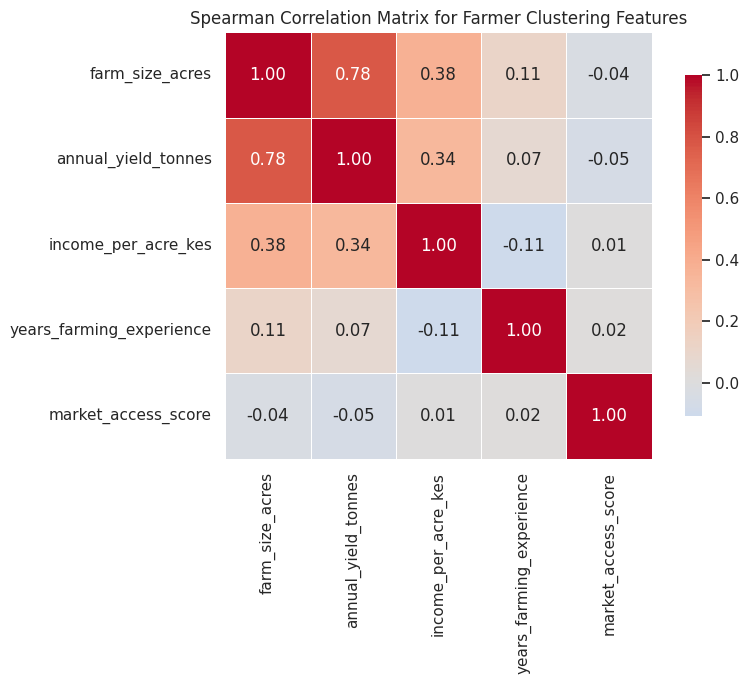

In [7]:
spearman_correlation = farmer_data[
    numeric_candidate_features
].corr(
    method="spearman"
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    spearman_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Spearman Correlation Matrix for Farmer Clustering Features"
)

plt.tight_layout()
plt.show()

**Interpretation of Correlated Clustering Features**

No pair of numeric clustering features has an absolute Spearman correlation of 0.80 or above. Therefore, no feature is removed because of strong redundancy.

The strongest relationship is between `farm_size_acres` and `annual_yield_tonnes`, with a correlation of 0.78. This is below the removal threshold but is still worth noting because farm size and total yield are naturally related.

The next strongest relationships are `farm_size_acres` with `income_per_acre_kes` at 0.38 and `annual_yield_tonnes` with `income_per_acre_kes` at 0.34. All other relationships are weak.

All five numeric features are retained for clustering. The possible overlap between farm size and annual yield will be considered again during the robustness check.

## 4. Feature Inclusion and Exclusion Decisions

K-Means clustering uses Euclidean distance to group similar farmers. Therefore, only numeric features that represent meaningful farmer characteristics will be included in the distance calculation.

`farmer_id` is excluded because it is an identifier and has no segmentation meaning. Including it would allow arbitrary identification numbers to influence the distance calculation.

`crop_type` is excluded from the K-Means distance calculation because it is categorical. Encoding crop type as numeric values or one-hot columns could distort Euclidean distance and give crop categories an unjustified influence on the clustering solution.

The numeric variables `farm_size_acres`, `annual_yield_tonnes`, `income_per_acre_kes`, `years_farming_experience`, and `market_access_score` are included because they describe farm scale, production, income efficiency, experience, and access to markets.

`crop_type` will be retained for post-hoc cluster profiling. This means that clusters will first be formed using numeric farmer characteristics, then crop-type distributions will be used to help interpret the resulting farmer segments.

In [8]:
clustering_features = [
    "farm_size_acres",
    "annual_yield_tonnes",
    "income_per_acre_kes",
    "years_farming_experience",
    "market_access_score",
]

X_clustering = farmer_data[
    clustering_features
].copy()

print("Features included in K-Means clustering:")
print(clustering_features)

print(
    "\nFeatures excluded from the distance calculation:"
)

print(
    "- farmer_id: identifier column"
)

print(
    "- crop_type: reserved for post-hoc cluster profiling"
)

display(X_clustering.head())

Features included in K-Means clustering:
['farm_size_acres', 'annual_yield_tonnes', 'income_per_acre_kes', 'years_farming_experience', 'market_access_score']

Features excluded from the distance calculation:
- farmer_id: identifier column
- crop_type: reserved for post-hoc cluster profiling


,farm_size_acres,annual_yield_tonnes,income_per_acre_kes,years_farming_experience,market_access_score
0,16.29,35.9,2000.0,7.0,51.718276
1,8.19,4.0,81018.0,3.9,60.453885
2,5.64,4.9,39787.0,4.7,17.004114
3,56.21,206.7,96659.0,17.4,39.364960
4,4.66,6.9,150561.0,9.3,52.062909


## 5. Preprocessing: Missing Data and Scaling

K-Means clustering uses Euclidean distance to group similar farmers. Therefore, all clustering features must be numeric, complete, and on a comparable scale.

`market_access_score` has 30 missing values. The missingness was spread similarly across crop types, so it is treated as likely random. Median imputation will be used because it is less affected by extreme values than mean imputation.

Standardization is essential because the clustering features have different units and ranges. For example, `income_per_acre_kes` is measured in Kenyan shillings, while `market_access_score` ranges from 0 to 100. Without scaling, income per acre would dominate the K-Means distance calculation.

In [9]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

clustering_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

X_scaled = clustering_preprocessor.fit_transform(
    X_clustering
)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=clustering_features,
    index=farmer_data.index
)

print("Before preprocessing:")
display(
    X_clustering
    .describe()
    .loc[["mean", "std"]]
    .round(2)
)

print("\nAfter median imputation and standardization:")
display(
    X_scaled_df
    .describe()
    .loc[["mean", "std"]]
    .round(4)
)

Before preprocessing:


,farm_size_acres,annual_yield_tonnes,income_per_acre_kes,years_farming_experience,market_access_score
mean,10.16,30.71,51914.35,10.25,52.86
std,14.58,55.53,40581.50,6.04,22.96



After median imputation and standardization:


,farm_size_acres,annual_yield_tonnes,income_per_acre_kes,years_farming_experience,market_access_score
mean,-0.0000,-0.0000,0.0000,0.0000,-0.0000
std,1.0007,1.0007,1.0007,1.0007,1.0007


**Interpretation of Preprocessing**

Median imputation was applied to the 30 missing `market_access_score` values. The missingness pattern was similar across crop types, so the values were treated as likely random rather than structural.

All five numeric clustering features were standardized successfully. Their means are approximately zero and their standard deviations are approximately one.

The displayed standard deviation of 1.0007 is expected because `StandardScaler` uses population standard deviation while the Pandas summary table uses sample standard deviation. The features are correctly scaled and can now be used fairly in the K-Means distance calculation.

## 6. Determining the Optimal Number of Clusters

K-Means requires the number of clusters, represented by $k$, to be chosen before clustering begins.

The final value of $k$ will not be selected using the elbow plot alone. Four methods will be compared across several possible values of $k$:

- Inertia, used in the elbow method: lower values are better, but inertia always decreases as $k$ increases.
- Silhouette score: higher values indicate more distinct and well-separated clusters.
- Davies-Bouldin index: lower values indicate more distinct clusters.
- Calinski-Harabasz index: higher values indicate better separation between clusters compared with variation within clusters.

The final decision will consider agreement between these methods, cluster size balance, interpretability, and the practical usefulness of the farmer segments.

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

k_range = range(2, 11)

k_selection_results = []

for k in k_range:
    kmeans_candidate = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    cluster_labels = kmeans_candidate.fit_predict(
        X_scaled
    )

    k_selection_results.append(
        {
            "k": k,
            "inertia": kmeans_candidate.inertia_,
            "silhouette_score": silhouette_score(
                X_scaled,
                cluster_labels
            ),
            "davies_bouldin_score": davies_bouldin_score(
                X_scaled,
                cluster_labels
            ),
            "calinski_harabasz_score": calinski_harabasz_score(
                X_scaled,
                cluster_labels
            ),
        }
    )

k_selection_df = pd.DataFrame(
    k_selection_results
)

display(k_selection_df.round(4))

,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,2122.6803,0.5179,0.7659,407.9855
1,3,1641.5843,0.3634,1.0067,362.5910
2,4,1313.2994,0.2899,1.1740,358.0366
3,5,1091.0890,0.2920,1.0456,357.1008
4,6,981.8484,0.3084,1.0155,331.9930
5,7,879.0322,0.3026,1.0109,321.6817
6,8,811.5401,0.3004,1.0696,306.1983
7,9,760.3023,0.2945,1.0535,291.2061
8,10,711.0937,0.2694,1.2306,281.5018


### Preliminary Cluster-Number Results

The cluster-validity results show that $k=2$ is the strongest statistical solution so far. It has the highest silhouette score of 0.5179, the lowest Davies-Bouldin score of 0.7659, and the highest Calinski-Harabasz score of 407.9855.

A silhouette score above 0.5 suggests that the two clusters are reasonably distinct. The lower Davies-Bouldin score also indicates that the clusters are more separated and internally consistent than the solutions with larger values of $k$.

The inertia value decreases as $k$ increases, which is expected because more clusters always reduce within-cluster variation. Therefore, inertia will be interpreted using the elbow pattern rather than its lowest value.

Although $k=2$ is currently the strongest statistical candidate, $k=3$ will also be examined because it is the next-best candidate on the silhouette and Calinski-Harabasz measures. The final decision will consider statistical evidence, cluster sizes, and whether the farmer segments are useful for cooperative decision-making.

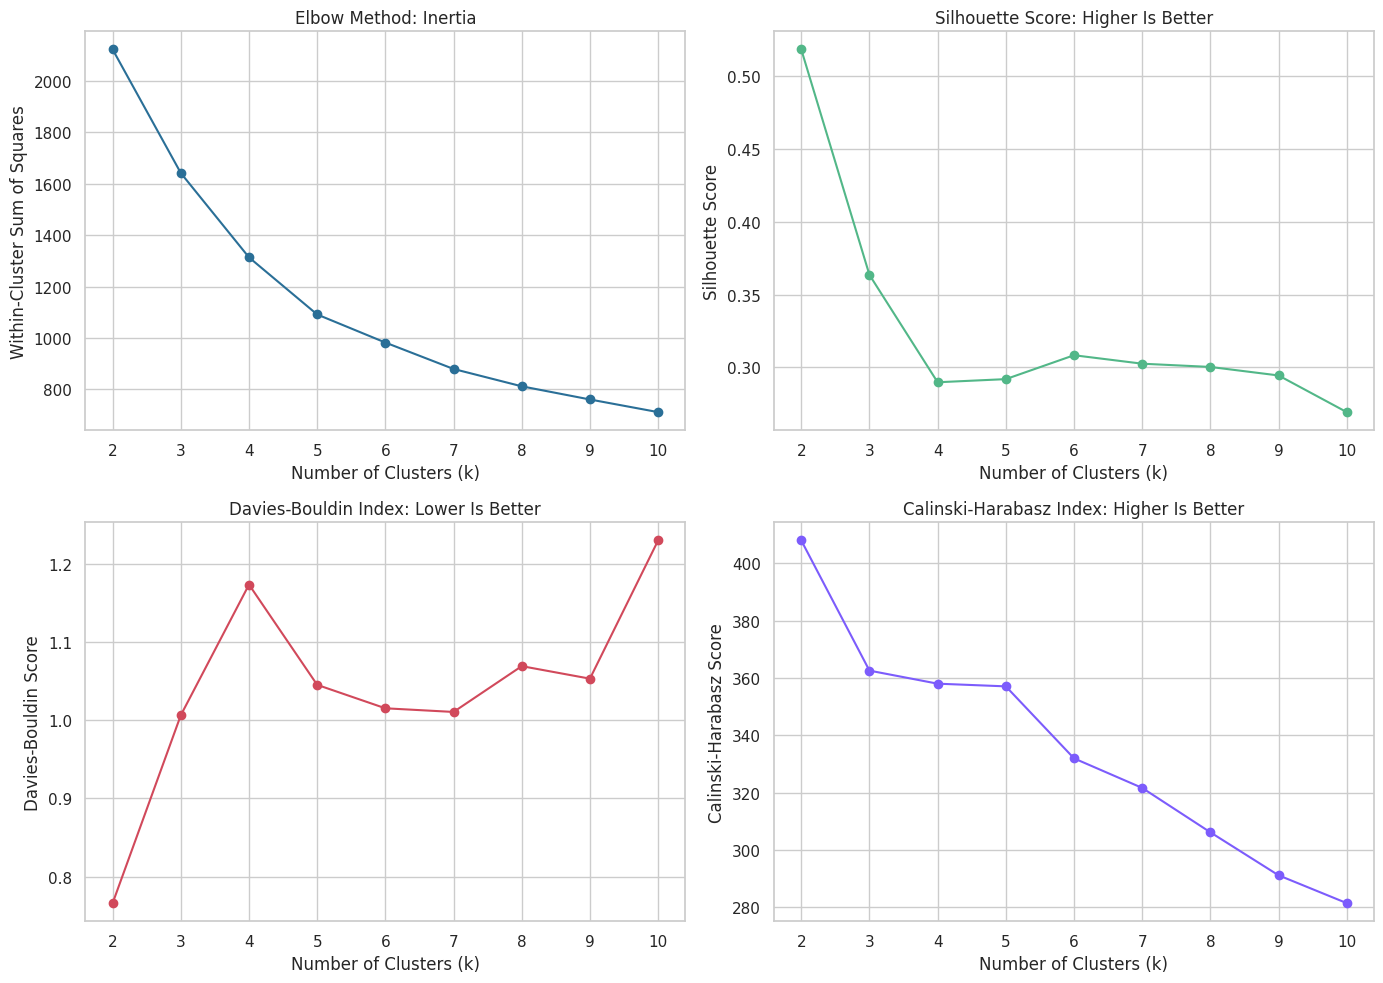

In [11]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

axes[0, 0].plot(
    k_selection_df["k"],
    k_selection_df["inertia"],
    marker="o",
    color="#2A6F97"
)

axes[0, 0].set_title("Elbow Method: Inertia")
axes[0, 0].set_xlabel("Number of Clusters (k)")
axes[0, 0].set_ylabel("Within-Cluster Sum of Squares")

axes[0, 1].plot(
    k_selection_df["k"],
    k_selection_df["silhouette_score"],
    marker="o",
    color="#52B788"
)

axes[0, 1].set_title("Silhouette Score: Higher Is Better")
axes[0, 1].set_xlabel("Number of Clusters (k)")
axes[0, 1].set_ylabel("Silhouette Score")

axes[1, 0].plot(
    k_selection_df["k"],
    k_selection_df["davies_bouldin_score"],
    marker="o",
    color="#D1495B"
)

axes[1, 0].set_title("Davies-Bouldin Index: Lower Is Better")
axes[1, 0].set_xlabel("Number of Clusters (k)")
axes[1, 0].set_ylabel("Davies-Bouldin Score")

axes[1, 1].plot(
    k_selection_df["k"],
    k_selection_df["calinski_harabasz_score"],
    marker="o",
    color="#7C5CFC"
)

axes[1, 1].set_title("Calinski-Harabasz Index: Higher Is Better")
axes[1, 1].set_xlabel("Number of Clusters (k)")
axes[1, 1].set_ylabel("Calinski-Harabasz Score")

plt.tight_layout()
plt.show()

### Comparing Candidate Cluster Solutions

The validity metrics strongly favour $k=2$, while $k=3$ is the next strongest candidate.

Before selecting the final number of clusters, both solutions are compared using cluster size balance and the original farmer characteristics within each cluster.

Cluster labels such as 0, 1, and 2 do not represent a ranking. They are only labels assigned by the K-Means algorithm.

In [12]:
candidate_ks = [2, 3]

candidate_models = {}
candidate_cluster_labels = {}
candidate_comparison_rows = []

for k in candidate_ks:
    candidate_model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    candidate_labels = candidate_model.fit_predict(
        X_scaled
    )

    candidate_models[k] = candidate_model
    candidate_cluster_labels[k] = candidate_labels

    cluster_sizes = (
        pd.Series(candidate_labels)
        .value_counts()
        .sort_index()
    )

    candidate_comparison_rows.append(
        {
            "k": k,
            "inertia": candidate_model.inertia_,
            "silhouette_score": silhouette_score(
                X_scaled,
                candidate_labels
            ),
            "davies_bouldin_score": davies_bouldin_score(
                X_scaled,
                candidate_labels
            ),
            "calinski_harabasz_score": calinski_harabasz_score(
                X_scaled,
                candidate_labels
            ),
            "smallest_cluster_size": cluster_sizes.min(),
            "largest_cluster_size": cluster_sizes.max(),
        }
    )

candidate_comparison_df = pd.DataFrame(
    candidate_comparison_rows
)

display(candidate_comparison_df.round(4))

for k in candidate_ks:
    farmer_data_with_candidate_cluster = (
        farmer_data.copy()
    )

    farmer_data_with_candidate_cluster[
        "candidate_cluster"
    ] = candidate_cluster_labels[k]

    cluster_sizes = (
        farmer_data_with_candidate_cluster[
            "candidate_cluster"
        ]
        .value_counts()
        .sort_index()
    )

    candidate_profile = (
        farmer_data_with_candidate_cluster
        .groupby("candidate_cluster")[
            clustering_features
        ]
        .mean()
    )

    candidate_profile.insert(
        0,
        "farmer_count",
        cluster_sizes
    )

    print(f"\nCluster profiles for k={k}:")
    display(candidate_profile.round(2))

,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score,smallest_cluster_size,largest_cluster_size
0,2,2122.6803,0.5179,0.7659,407.9855,80,600
1,3,1641.5843,0.3634,1.0067,362.5910,80,499



Cluster profiles for k=2:


,farmer_count,farm_size_acres,annual_yield_tonnes,income_per_acre_kes,years_farming_experience,market_access_score
candidate_cluster,,,,,,
0,600,5.77,11.42,47358.21,9.28,52.83
1,80,43.10,175.38,86085.39,17.57,53.12



Cluster profiles for k=3:


,farmer_count,farm_size_acres,annual_yield_tonnes,income_per_acre_kes,years_farming_experience,market_access_score
candidate_cluster,,,,,,
0,499,6.15,12.15,31139.99,9.51,52.78
1,80,43.10,175.38,86085.39,17.57,53.12
2,101,3.93,7.79,127485.83,8.12,53.10


### Preliminary Comparison of k=2 and k=3

The statistical validity measures favour $k=2$. It has a silhouette score of 0.5179, which is higher than the $k=3$ score of 0.3634. It also has a lower Davies-Bouldin score and a higher Calinski-Harabasz score.

The $k=2$ solution creates two broad farmer groups. One group contains 600 farmers with smaller farms, lower yields, lower income per acre, and less farming experience. The second group contains 80 farmers with much larger farms, higher yields, higher income per acre, and more farming experience.

The $k=3$ solution retains the large commercial-farmer group of 80 farmers. It also separates 101 smaller farms with high income per acre from 499 farmers with lower income per acre.

Although $k=3$ has weaker validity scores than $k=2$, it may provide a more useful farmer segmentation if the high-income-per-acre group represents a distinct and actionable cooperative segment. Crop-type profiling will be examined before making the final decision.

In [13]:
for k in candidate_ks:
    candidate_profile_data = farmer_data.copy()

    candidate_profile_data[
        "candidate_cluster"
    ] = candidate_cluster_labels[k]

    crop_profile = (
        pd.crosstab(
            candidate_profile_data[
                "candidate_cluster"
            ],
            candidate_profile_data[
                profiling_categorical_feature
            ],
            normalize="index"
        )
        * 100
    )

    print(
        f"\nCrop-type distribution within clusters for k={k} (%):"
    )

    display(crop_profile.round(1))


Crop-type distribution within clusters for k=2 (%):


crop_type,Coffee,Dairy,Horticulture,Maize,Tea
candidate_cluster,,,,,
0,18.0,15.3,19.2,31.8,15.7
1,13.8,11.2,25.0,31.2,18.8



Crop-type distribution within clusters for k=3 (%):


crop_type,Coffee,Dairy,Horticulture,Maize,Tea
candidate_cluster,,,,,
0,18.6,15.2,19.4,31.1,15.6
1,13.8,11.2,25.0,31.2,18.8
2,14.9,15.8,17.8,35.6,15.8


### Final Choice of the Number of Clusters

The final K-Means solution uses $k=2$ clusters.

Although $k=3$ separates a smaller group of farmers with high income per acre, the statistical validity measures strongly favour $k=2$. The $k=2$ solution has a higher silhouette score of 0.5179, a lower Davies-Bouldin score of 0.7659, and a higher Calinski-Harabasz score of 407.9855.

The $k=2$ solution creates two meaningful farmer segments. One cluster contains 600 farmers with smaller farms, lower yields, lower income per acre, and less farming experience. The other cluster contains 80 farmers with substantially larger farms, higher yields, higher income per acre, and more farming experience.

The $k=3$ solution adds a group of 101 smaller farms with high income per acre. However, this additional group does not have a strongly distinct crop-type profile, and the clustering validity scores are weaker than for $k=2`.

Therefore, $k=2$ is selected because it provides the strongest statistical separation and a simpler, more defensible farmer segmentation for cooperative decision-making.

## 7. Final K-Means Clustering Solution

K-Means is fitted using the selected value of $k=2$ and the standardized numeric farmer features.

The resulting cluster labels are used only to identify groups of similar farmers. Cluster labels do not represent a ranking of farmers from better to worse.

In [14]:
FINAL_K = 2

final_kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=20
)

final_cluster_labels = final_kmeans.fit_predict(
    X_scaled
)

farmer_clusters = farmer_data.copy()

farmer_clusters["cluster"] = (
    final_cluster_labels
)

print(f"Final number of clusters: {FINAL_K}")

display(farmer_clusters.head())

Final number of clusters: 2


,farmer_id,crop_type,farm_size_acres,annual_yield_tonnes,income_per_acre_kes,years_farming_experience,market_access_score,cluster
0,1,Horticulture,16.29,35.9,2000.0,7.0,51.718276,0
1,2,Maize,8.19,4.0,81018.0,3.9,60.453885,0
2,3,Dairy,5.64,4.9,39787.0,4.7,17.004114,0
3,4,Maize,56.21,206.7,96659.0,17.4,39.364960,1
4,5,Maize,4.66,6.9,150561.0,9.3,52.062909,0


## 8. Cluster Diagnostics

Cluster diagnostics are used to check whether the final K-Means solution is reasonable.

The cluster-size check confirms that no cluster is nearly empty. The silhouette score, Davies-Bouldin index, and Calinski-Harabasz index are reported again for the final $k=2$ solution to confirm that the selected clusters remain distinct and well separated.

In [15]:
final_cluster_sizes = (
    farmer_clusters["cluster"]
    .value_counts()
    .sort_index()
)

final_cluster_percentages = (
    farmer_clusters["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

final_silhouette_score = silhouette_score(
    X_scaled,
    final_cluster_labels
)

final_davies_bouldin_score = davies_bouldin_score(
    X_scaled,
    final_cluster_labels
)

final_calinski_harabasz_score = (
    calinski_harabasz_score(
        X_scaled,
        final_cluster_labels
    )
)

cluster_diagnostics = pd.DataFrame(
    {
        "cluster_size": final_cluster_sizes,
        "cluster_percentage": final_cluster_percentages,
    }
)

print("Final cluster sizes:")
display(cluster_diagnostics.round(2))

final_validity_summary = pd.DataFrame(
    {
        "metric": [
            "Silhouette score",
            "Davies-Bouldin score",
            "Calinski-Harabasz score",
        ],
        "value": [
            final_silhouette_score,
            final_davies_bouldin_score,
            final_calinski_harabasz_score,
        ],
        "preferred_direction": [
            "Higher is better",
            "Lower is better",
            "Higher is better",
        ],
    }
)

print("\nFinal validity metrics for k=2:")
display(final_validity_summary.round(4))

Final cluster sizes:


,cluster_size,cluster_percentage
cluster,,
0,600,88.24
1,80,11.76



Final validity metrics for k=2:


,metric,value,preferred_direction
0,Silhouette score,0.5179,Higher is better
1,Davies-Bouldin score,0.7659,Lower is better
2,Calinski-Harabasz score,407.9855,Higher is better


**Interpretation of Final Cluster Diagnostics**

The final $k=2$ solution produced two clusters with different sizes. Cluster 0 contains 600 farmers, representing 88.24% of the dataset. Cluster 1 contains 80 farmers, representing 11.76% of the dataset.

The clusters are not equally sized, but Cluster 1 is not near-empty. It contains 80 farmers and represents a meaningful smaller farmer segment rather than a small number of unusual observations.

The final silhouette score is 0.5179. This suggests that the two clusters are reasonably distinct and that farmers are generally more similar to members of their own cluster than to farmers in the other cluster.

The Davies-Bouldin score is 0.7659. Since lower values are better, this supports the conclusion that the two clusters are relatively well separated.

The Calinski-Harabasz score is 407.9855. This was the highest value among the tested cluster solutions, indicating strong separation between the two clusters relative to variation within them.

Overall, the final $k=2$ solution is statistically supported and produces two meaningful farmer segments: a large group of smaller-scale farmers and a smaller group of larger, higher-yield farmers.

## 9. Visualizing the Final Clusters

The final clusters are visualized using pairs of original farmer characteristics. The cluster labels are shown using different colours.

These visualizations use the original feature values so that the farmer segments can be interpreted in practical units such as acres, tonnes, Kenyan shillings, and years of farming experience.

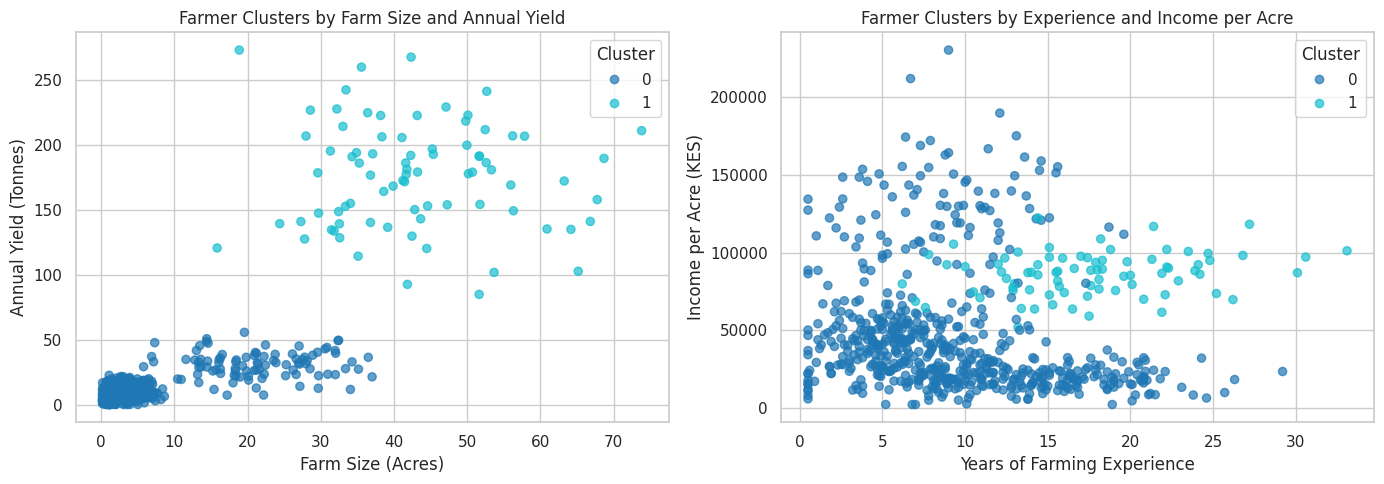

In [16]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

scatter_1 = axes[0].scatter(
    farmer_clusters["farm_size_acres"],
    farmer_clusters["annual_yield_tonnes"],
    c=farmer_clusters["cluster"],
    cmap="tab10",
    s=35,
    alpha=0.7
)

axes[0].set_title(
    "Farmer Clusters by Farm Size and Annual Yield"
)

axes[0].set_xlabel("Farm Size (Acres)")
axes[0].set_ylabel("Annual Yield (Tonnes)")

axes[0].legend(
    *scatter_1.legend_elements(),
    title="Cluster"
)

scatter_2 = axes[1].scatter(
    farmer_clusters["years_farming_experience"],
    farmer_clusters["income_per_acre_kes"],
    c=farmer_clusters["cluster"],
    cmap="tab10",
    s=35,
    alpha=0.7
)

axes[1].set_title(
    "Farmer Clusters by Experience and Income per Acre"
)

axes[1].set_xlabel("Years of Farming Experience")
axes[1].set_ylabel("Income per Acre (KES)")

axes[1].legend(
    *scatter_2.legend_elements(),
    title="Cluster"
)

plt.tight_layout()
plt.show()

**Interpretation of Cluster Visualizations**

The farm size and annual yield plot shows clear visual separation between the two clusters. Cluster 0 contains the larger group of mainly smaller farms with lower total yields. Cluster 1 contains a smaller group of larger farms with substantially higher annual yields.

The experience and income-per-acre plot shows more overlap between the clusters. However, Cluster 1 is concentrated among farmers with higher farming experience and a narrower range of income per acre. Cluster 0 contains farmers with a wider range of income per acre and experience levels.

The plots support the final cluster profiles. Cluster 1 represents a smaller group of larger, high-yield, more experienced farmers. Cluster 0 represents the larger group of smaller-scale farmers with more varied income efficiency.

Although some smaller farms in Cluster 0 have high income per acre, Cluster 1 has a higher average income per acre overall. The $k=3$ solution was examined because the visual pattern suggested a possible subgroup, but its clustering validity scores were weaker than those for $k=2`. Therefore, the two-cluster solution remains the final choice.

## 10. Cluster Profiling and Business Interpretation

K-Means creates the clusters, but cluster profiling explains what the clusters mean in practical terms.

The clusters are profiled using the mean and standard deviation of the numeric clustering features. `crop_type` is also used after clustering to compare the crop mix within each segment.

Crop type was deliberately excluded from the K-Means distance calculation. It is used here only to help interpret the farmer segments after they have been formed.

In [17]:
cluster_profile_means = (
    farmer_clusters
    .groupby("cluster")[clustering_features]
    .mean()
    .add_suffix("_mean")
)

cluster_profile_std = (
    farmer_clusters
    .groupby("cluster")[clustering_features]
    .std()
    .add_suffix("_std")
)

cluster_profile = cluster_profile_means.join(
    cluster_profile_std
)

cluster_profile.insert(
    0,
    "farmer_count",
    farmer_clusters["cluster"]
    .value_counts()
    .sort_index()
)

print("Final cluster profile: means and standard deviations")
display(cluster_profile.round(2))

crop_type_profile = (
    pd.crosstab(
        farmer_clusters["cluster"],
        farmer_clusters["crop_type"],
        normalize="index"
    )
    * 100
)

print("\nCrop-type distribution within each cluster (%):")
display(crop_type_profile.round(1))

Final cluster profile: means and standard deviations


,farmer_count,farm_size_acres_mean,annual_yield_tonnes_mean,income_per_acre_kes_mean,years_farming_experience_mean,market_access_score_mean,farm_size_acres_std,annual_yield_tonnes_std,income_per_acre_kes_std,years_farming_experience_std,market_access_score_std
cluster,,,,,,,,,,,
0,600,5.77,11.42,47358.21,9.28,52.83,7.64,10.58,40801.53,5.40,23.30
1,80,43.10,175.38,86085.39,17.57,53.12,11.81,40.44,13850.24,5.57,20.31



Crop-type distribution within each cluster (%):


crop_type,Coffee,Dairy,Horticulture,Maize,Tea
cluster,,,,,
0,18.0,15.3,19.2,31.8,15.7
1,13.8,11.2,25.0,31.2,18.8


### Farmer Segment Interpretation

The final clustering solution identifies two meaningful farmer segments.

| Cluster | Segment Name | Farmer Profile |
|---|---|---|
| 0 | Smallholder and Variable-Return Farmers | This segment contains 600 farmers. On average, they operate smaller farms of 5.77 acres, produce 11.42 tonnes annually, earn 47,358.21 KES per acre, and have 9.28 years of farming experience. Their income per acre has a large standard deviation, showing that income efficiency varies widely within this group. |
| 1 | Established Commercial High-Yield Farmers | This segment contains 80 farmers. On average, they operate larger farms of 43.10 acres, produce 175.38 tonnes annually, earn 86,085.39 KES per acre, and have 17.57 years of farming experience. Their income per acre is higher and less variable than that of Cluster 0. |

Market access does not strongly distinguish the clusters because both groups have similar average market-access scores of approximately 53.

Maize is the most common crop type in both clusters. Cluster 1 has a slightly higher proportion of Horticulture and Tea farmers, but crop type does not appear to be the main driver of the segmentation.

The cooperative could use these segments to provide different forms of support. Smallholder and Variable-Return Farmers may benefit from productivity support, extension services, financial training, and assistance to improve income per acre. Established Commercial High-Yield Farmers may benefit from larger-scale finance, bulk input purchasing, advanced production support, and stronger market-linkage opportunities.

These segments describe patterns in the available data. They should support cooperative planning rather than be treated as fixed labels for every farmer.

In [18]:
segment_names = {
    0: "Smallholder and Variable-Return Farmers",
    1: "Established Commercial High-Yield Farmers",
}

farmer_clusters["segment_name"] = (
    farmer_clusters["cluster"]
    .map(segment_names)
)

display(
    farmer_clusters[
        [
            "farmer_id",
            "crop_type",
            "cluster",
            "segment_name",
        ]
    ].head()
)

,farmer_id,crop_type,cluster,segment_name
0,1,Horticulture,0,Smallholder and Variable-Return Farmers
1,2,Maize,0,Smallholder and Variable-Return Farmers
2,3,Dairy,0,Smallholder and Variable-Return Farmers
3,4,Maize,1,Established Commercial High-Yield Farmers
4,5,Maize,0,Smallholder and Variable-Return Farmers


## 11. Robustness and Sensitivity Check

K-Means can be sensitive to the scaling method used, especially when features contain potential outliers.

The main clustering solution used `StandardScaler`, which standardizes each feature using its mean and standard deviation. A second K-Means solution will use `RobustScaler`, which uses the median and interquartile range and is less affected by extreme values.

Both solutions use the same five clustering features and the same final value of $k=2$. The results will be compared using cluster sizes, validity metrics, and the Adjusted Rand Index.

In [19]:
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import RobustScaler

robust_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            RobustScaler(),
        ),
    ]
)

X_robust_scaled = robust_preprocessor.fit_transform(
    X_clustering
)

robust_kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=20
)

robust_cluster_labels = robust_kmeans.fit_predict(
    X_robust_scaled
)

robust_cluster_sizes = (
    pd.Series(robust_cluster_labels)
    .value_counts()
    .sort_index()
)

scaling_sensitivity_comparison = pd.DataFrame(
    {
        "scaling_method": [
            "StandardScaler",
            "RobustScaler",
        ],
        "silhouette_score": [
            final_silhouette_score,
            silhouette_score(
                X_robust_scaled,
                robust_cluster_labels
            ),
        ],
        "davies_bouldin_score": [
            final_davies_bouldin_score,
            davies_bouldin_score(
                X_robust_scaled,
                robust_cluster_labels
            ),
        ],
        "calinski_harabasz_score": [
            final_calinski_harabasz_score,
            calinski_harabasz_score(
                X_robust_scaled,
                robust_cluster_labels
            ),
        ],
        "smallest_cluster_size": [
            final_cluster_sizes.min(),
            robust_cluster_sizes.min(),
        ],
        "largest_cluster_size": [
            final_cluster_sizes.max(),
            robust_cluster_sizes.max(),
        ],
    }
)

cluster_assignment_stability = adjusted_rand_score(
    final_cluster_labels,
    robust_cluster_labels
)

display(
    scaling_sensitivity_comparison.round(4)
)

print(
    "Adjusted Rand Index between StandardScaler and "
    f"RobustScaler cluster assignments: "
    f"{cluster_assignment_stability:.4f}"
)

print("\nRobustScaler cluster sizes:")
print(robust_cluster_sizes)

,scaling_method,silhouette_score,davies_bouldin_score,calinski_harabasz_score,smallest_cluster_size,largest_cluster_size
0,StandardScaler,0.5179,0.7659,407.9855,80,600
1,RobustScaler,0.7879,0.3784,2482.4882,80,600


Adjusted Rand Index between StandardScaler and RobustScaler cluster assignments: 1.0000

RobustScaler cluster sizes:
0    600
1     80
Name: count, dtype: int64


**Interpretation of the Robustness Check**

The robustness check compared the final $k=2$ solution using StandardScaler and RobustScaler.

RobustScaler is less sensitive to extreme values because it uses the median and interquartile range rather than the mean and standard deviation. This is relevant because farm size and annual yield contained several potential outliers.

The StandardScaler and RobustScaler solutions produced the same cluster sizes: 600 farmers in Cluster 0 and 80 farmers in Cluster 1. The Adjusted Rand Index is 1.0000, meaning that the two scaling methods assigned the farmers to the same clusters.

The clustering validity metrics also remained favourable under RobustScaler. This shows that the two-cluster conclusion is stable and is not dependent on one specific scaling method.

StandardScaler is retained as the main preprocessing approach because it was used consistently during the original cluster-number selection process. RobustScaler confirms that the identified farmer segments remain stable even when the effect of extreme values is reduced.

## 12. Model Persistence

The fitted preprocessing pipeline and the fitted K-Means model are saved together so that new farmers can be assigned to the existing clusters correctly.

Saving the K-Means model alone is not enough. A new farmer must first be processed using the same fitted median imputer and StandardScaler used during clustering. Otherwise, the cluster assignment would be based on a different feature scale and would not be reliable.

In [20]:
model_path = (
    "d10_agricultural_cooperative_farmer_kmeans_clustering.joblib"
)

clustering_artifact = {
    "preprocessor": clustering_preprocessor,
    "kmeans": final_kmeans,
    "clustering_features": clustering_features,
    "segment_names": segment_names,
    "final_k": FINAL_K,
}

joblib.dump(
    clustering_artifact,
    model_path
)

loaded_artifact = joblib.load(
    model_path
)

print(
    "Saved and reloaded clustering artifact:"
)

print(model_path)

print(
    "\nSaved clustering features:"
)

print(
    loaded_artifact["clustering_features"]
)

print(
    "\nFinal number of clusters:"
)

print(
    loaded_artifact["final_k"]
)

Saved and reloaded clustering artifact:
d10_agricultural_cooperative_farmer_kmeans_clustering.joblib

Saved clustering features:
['farm_size_acres', 'annual_yield_tonnes', 'income_per_acre_kes', 'years_farming_experience', 'market_access_score']

Final number of clusters:
2


### New Farmer Cluster Assignment

A new farmer is assigned to an existing cluster using the reloaded preprocessing pipeline and K-Means model.

`crop_type` is not included in the cluster assignment because it was reserved for post-hoc profiling rather than used in the K-Means distance calculation.

In [21]:
loaded_preprocessor = loaded_artifact["preprocessor"]
loaded_kmeans = loaded_artifact["kmeans"]
loaded_features = loaded_artifact["clustering_features"]
loaded_segment_names = loaded_artifact["segment_names"]

new_farmer = pd.DataFrame(
    [
        {
            "farm_size_acres": 40.0,
            "annual_yield_tonnes": 160.0,
            "income_per_acre_kes": 85000.0,
            "years_farming_experience": 16.0,
            "market_access_score": 55.0,
        }
    ]
)

new_farmer = new_farmer[
    loaded_features
].copy()

new_farmer_scaled = loaded_preprocessor.transform(
    new_farmer
)

assigned_cluster = loaded_kmeans.predict(
    new_farmer_scaled
)[0]

assigned_segment = loaded_segment_names[
    assigned_cluster
]

print(f"Assigned cluster: {assigned_cluster}")
print(f"Farmer segment: {assigned_segment}")
print(f"Input rows: {len(new_farmer)}")
print("Output cluster assignments: 1")

Assigned cluster: 1
Farmer segment: Established Commercial High-Yield Farmers
Input rows: 1
Output cluster assignments: 1


**Interpretation of New Farmer Assignment**

The reloaded clustering artifact assigned the new farmer to Cluster 1, named Established Commercial High-Yield Farmers.

This result is consistent with the farmer's profile. The farmer has a large farm size of 40 acres, annual yield of 160 tonnes, income per acre of 85,000 KES, and 16 years of farming experience. These values are similar to the Cluster 1 profile.

The cluster assignment used the same saved median-imputation and StandardScaler steps used during the original clustering process. The new farmer was processed as one input row and received one cluster assignment.

Crop type was not used to assign the farmer to a cluster because it was reserved for post-hoc cluster profiling.

## 13. Conclusion and Recommendations

This analysis used K-Means clustering to segment 680 cooperative farmers using farm size, annual yield, income per acre, farming experience, and market access score.

The final solution used two clusters. The choice of $k=2$ was supported by the highest silhouette score of 0.5179, the lowest Davies-Bouldin score of 0.7659, and the highest Calinski-Harabasz score of 407.9855 among the tested values of $k$.

The first segment, Smallholder and Variable-Return Farmers, contains 600 farmers. These farmers have smaller farms, lower annual yields, lower average income per acre, and less farming experience. Their income per acre varies widely.

The second segment, Established Commercial High-Yield Farmers, contains 80 farmers. These farmers operate larger farms, produce higher annual yields, earn higher income per acre, and have more farming experience.

The robustness check produced an Adjusted Rand Index of 1.0000 when StandardScaler was compared with RobustScaler. This means that both scaling methods assigned farmers to the same two clusters. The two-cluster solution is therefore stable despite the presence of potential outliers.

The cooperative can use these segments to provide targeted support. Smallholder and Variable-Return Farmers may benefit from extension services, productivity support, financial training, and support to improve income per acre. Established Commercial High-Yield Farmers may benefit from larger-scale finance, bulk input purchasing, advanced production support, and stronger market-linkage opportunities.

This clustering analysis has limitations. It is based on a single dataset and five numeric features. Crop type was used only for profiling, and market access did not strongly separate the final clusters. The clusters describe patterns in the available data and should support cooperative planning rather than become fixed labels for individual farmers.